In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

In [6]:
x = torch.linspace(0, 1, 100).reshape(-1, 1)
y = torch.sin(2 * torch.pi * x) + 0.1 * torch.randn_like(x)

In [7]:
def train_model(x, y, lr=1e-3, epochs=3000):
    model = nn.Sequential(
        nn.Linear(1, 32), nn.Tanh(),
        nn.Linear(32, 32), nn.Tanh(),
        nn.Linear(32, 1)
    )

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        pred = model(x)
        loss = ((pred - y) ** 2).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return model

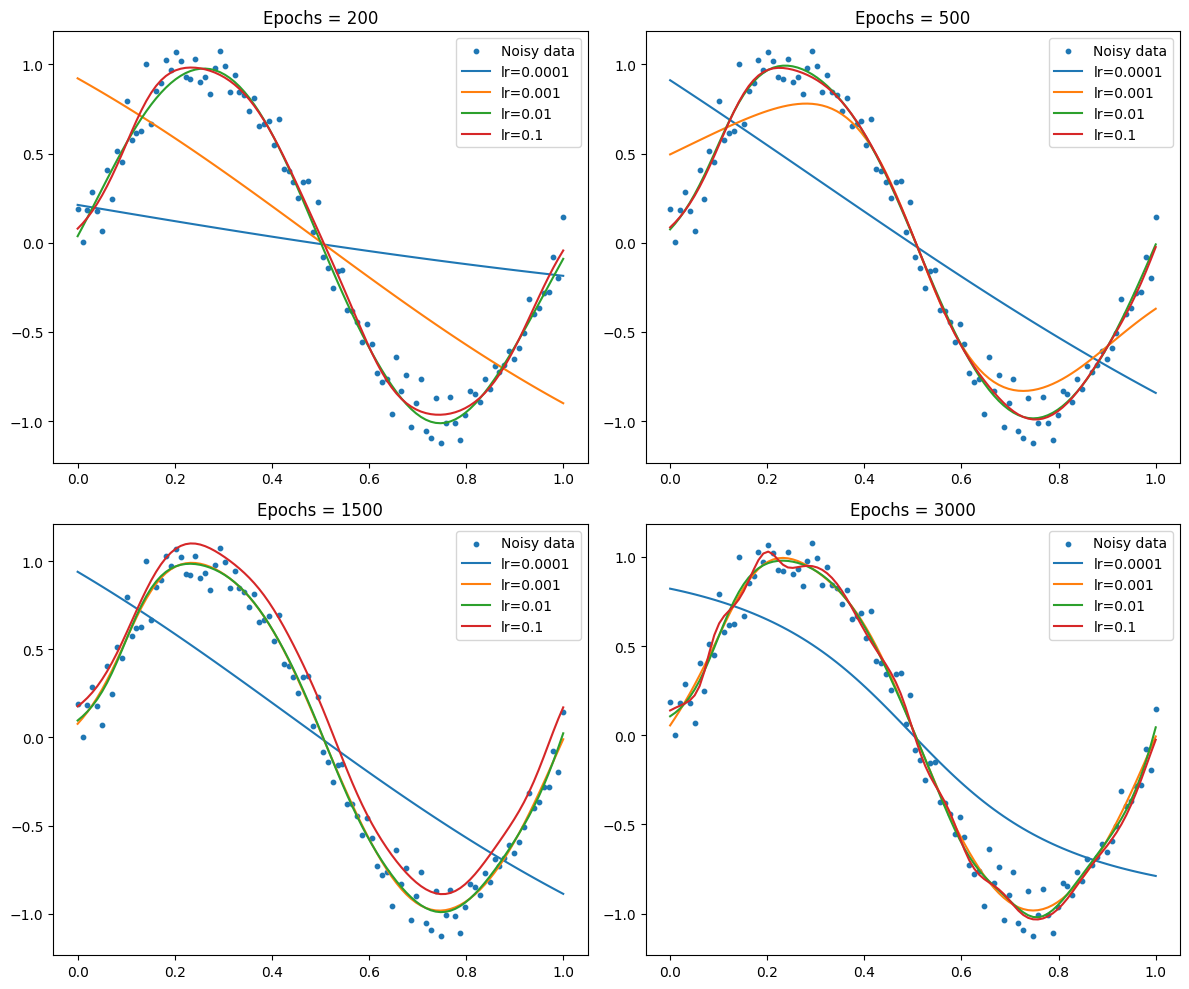

In [9]:
lrs = [1e-4, 1e-3, 1e-2, 1e-1]
epoch_list = [200, 500, 1500, 3000]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, epochs in enumerate(epoch_list):
    ax = axes[i]
    ax.scatter(x.detach(), y.detach(), s=10, label='Noisy data')

    for lr in lrs:
        model = train_model(x, y, lr=lr, epochs=epochs)

        with torch.no_grad():
            ax.plot(x.detach(), model(x).detach(), label=f"lr={lr}")

    ax.set_title(f"Epochs = {epochs}")
    ax.legend()

plt.tight_layout()
plt.show()